In [1]:
from ultralytics import YOLO

SEED = 42
model = YOLO("yolov8n.pt")

results = model.train(
    data=r"C:/Users/Acer/Downloads/Project CV/extracted_data/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    device=0,
    project="runs",
    name="traffic",
    exist_ok=True,
    seed=SEED,
    patience=10,
    close_mosaic=10,
)

# Print tiến trình huấn luyện
print("Training completed. Results:")
print(results)
# Lưu mô hình đã huấn luyện
model.save("yolov8n_traffic.pt")
# Đánh giá mô hình trên tập kiểm tra
metrics = model.val()
print("Evaluation metrics:")
print(metrics)

New https://pypi.org/project/ultralytics/8.4.38 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.33  Python-3.12.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:/Users/Acer/Downloads/Project CV/extracted_data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, 

In [2]:
from ultralytics import YOLO

model = YOLO(r"C:/Users/Acer/Downloads/Project CV/yolov8n_traffic.pt")

metrics = model.val(
    data=r"C:/Users/Acer/Downloads/Project CV/extracted_data/data.yaml",
    imgsz=640,
    batch=16,
    device=0,
    plots=True,        # tự sinh confusion_matrix, PR_curve...
    save_json=True,
    project="runs",
    name="traffic_eval",
    exist_ok=True,
)

print(f"mAP50:     {metrics.box.map50:.4f}")
print(f"mAP50-95:  {metrics.box.map:.4f}")
print(f"Precision: {metrics.box.mp:.4f}")
print(f"Recall:    {metrics.box.mr:.4f}")

Ultralytics 8.4.33  Python-3.12.0 torch-2.7.1+cu118 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
Model summary (fused): 73 layers, 3,010,133 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 34.423.9 MB/s, size: 8.6 KB)
val: Scanning C:\Users\Acer\Downloads\Project CV\extracted_data\labels\val.cache... 734 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 734/734  0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 7.1it/s 6.5s0.2s
                   all        734        734      0.889      0.863      0.908      0.812
                person         50         50      0.938       0.82      0.911      0.793
                   car        172        172       0.77      0.733      0.835      0.701
                 truck        167        167      0.706      0.659      0.769      0.644
                   bus         95         95      0.636      0.768      0.788      0.671
        

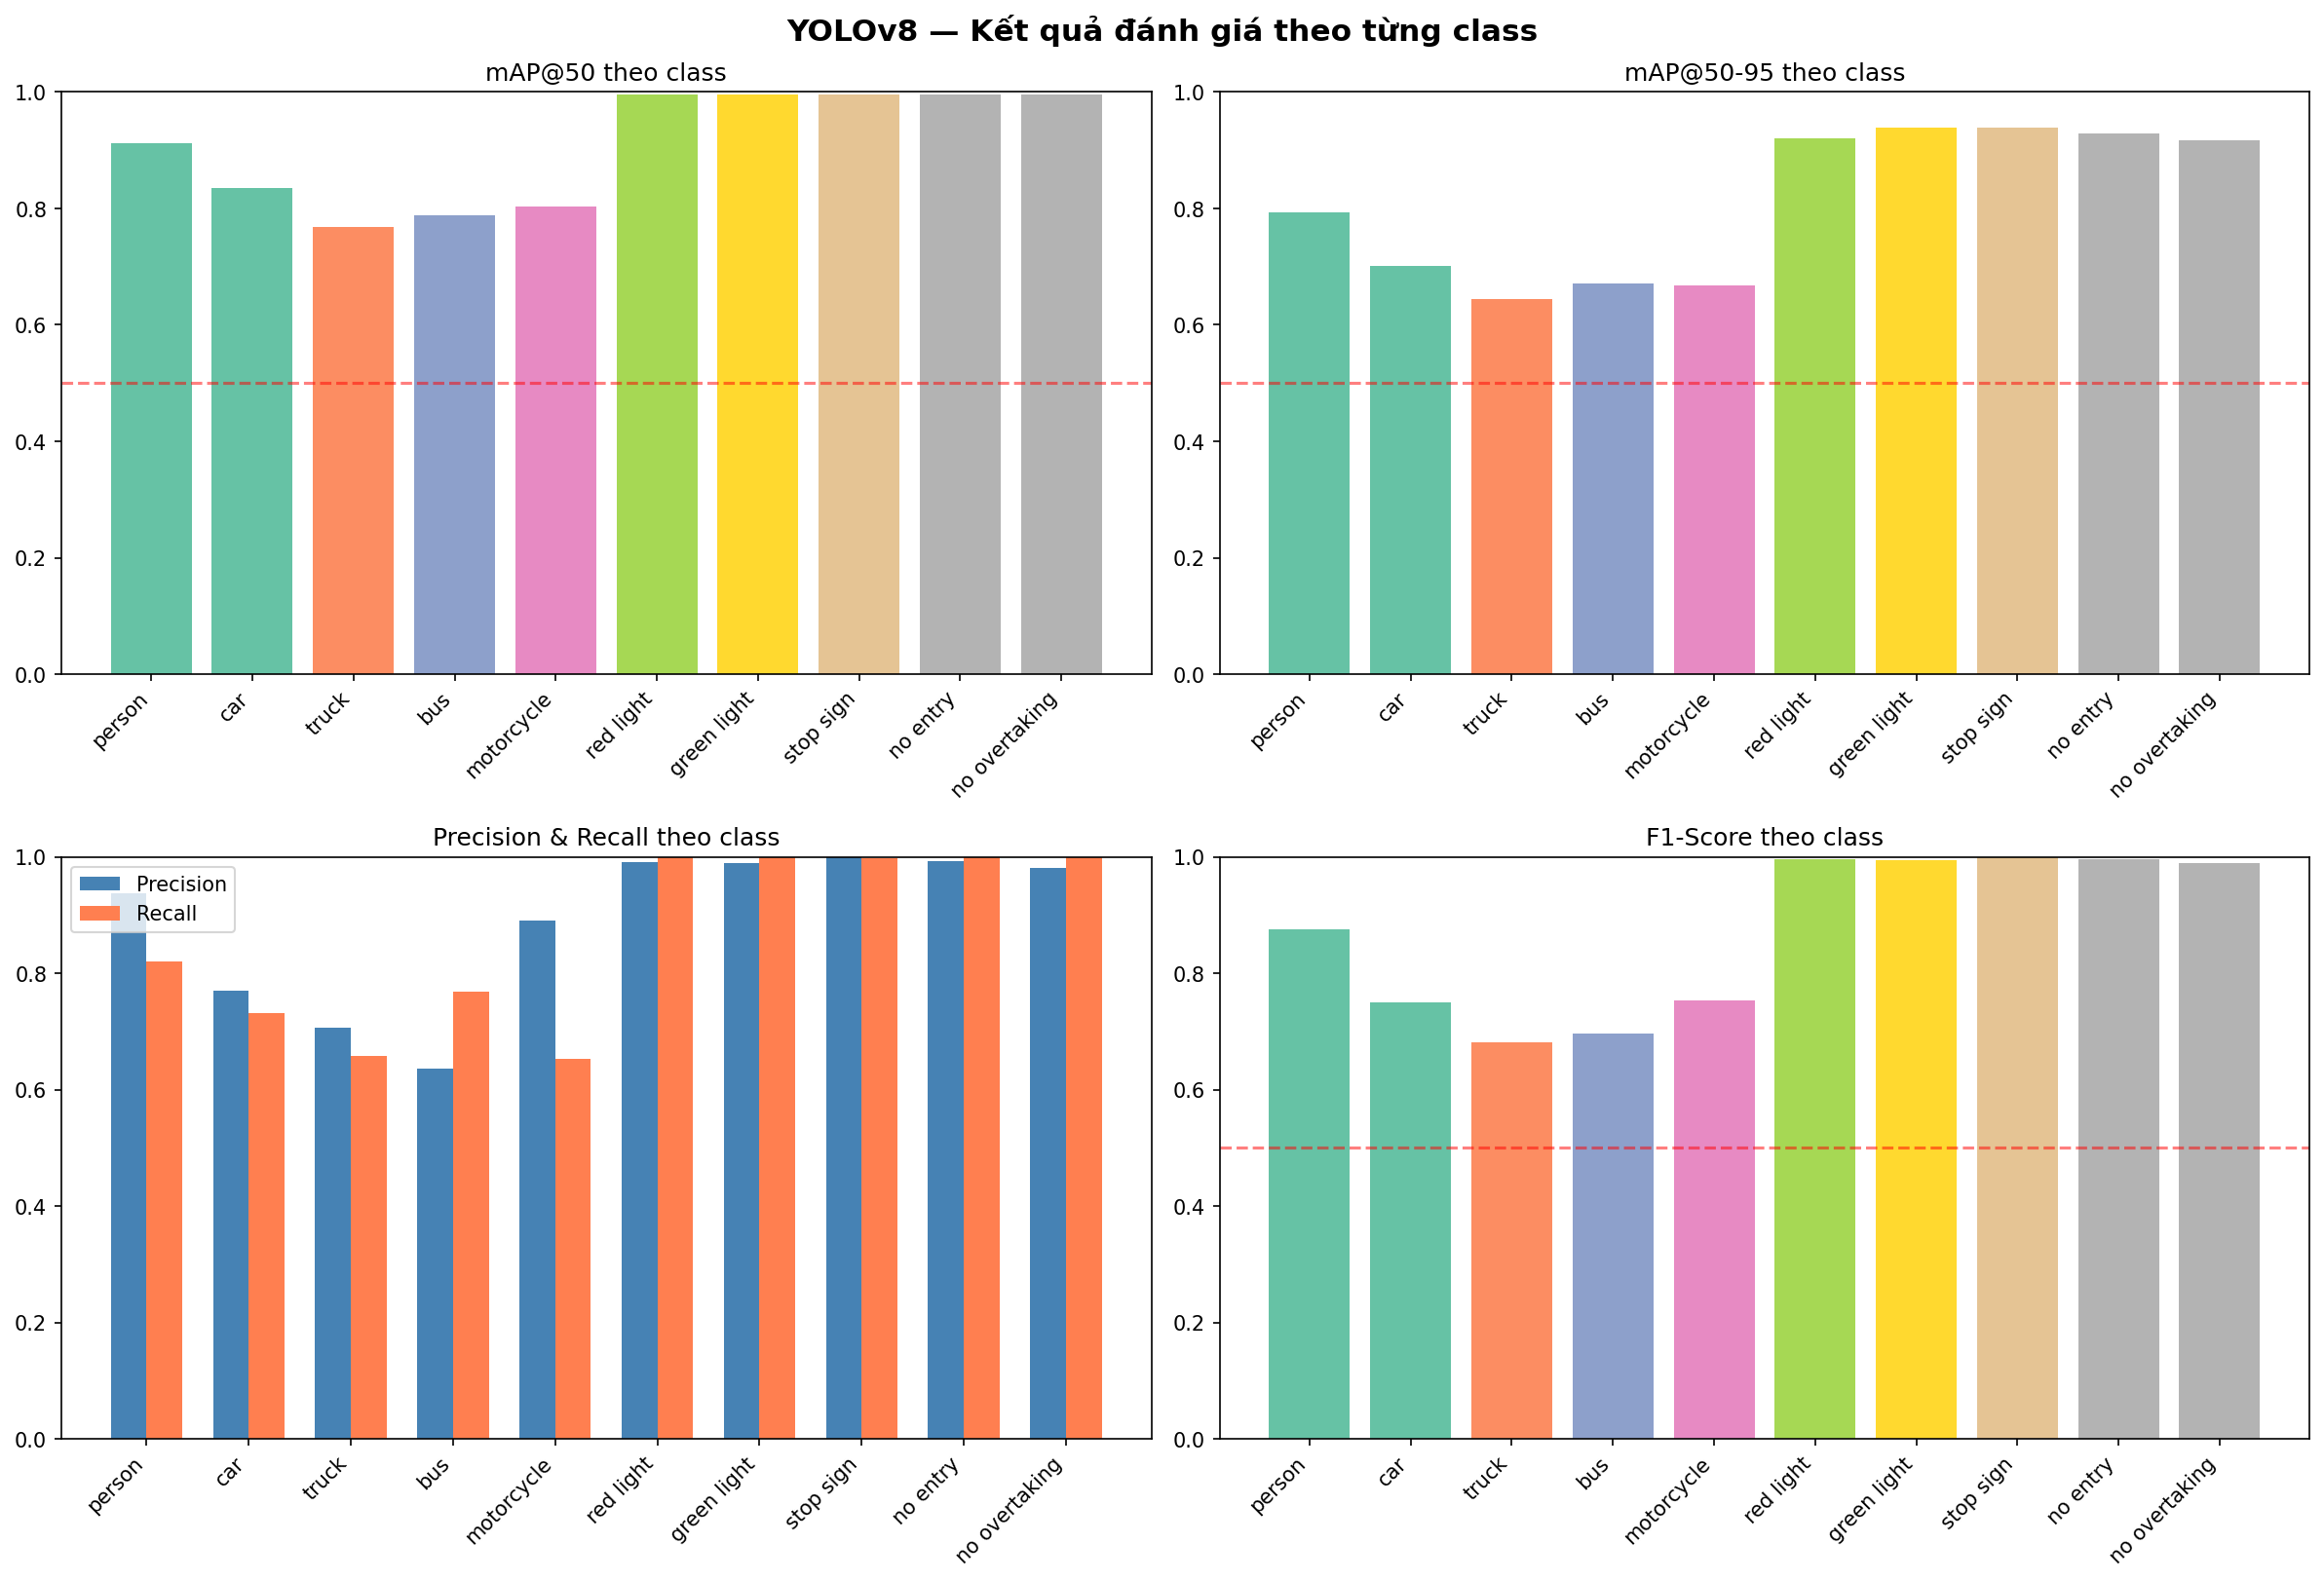

✅ Đã lưu tại: C:/Users/Acer/Downloads/Project CV/val_traffic_metrics.png


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import display, Image as IPImage

# Lấy metrics
map50_per  = metrics.box.ap50
map_per    = metrics.box.ap
precision  = metrics.box.p
recall     = metrics.box.r
f1         = 2 * (precision * recall) / (precision + recall + 1e-9)

n      = len(map50_per)
names  = [model.names[i] for i in range(n)]
x      = np.arange(n)
colors = plt.cm.Set2(np.linspace(0, 1, n))

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle("YOLOv8 — Kết quả đánh giá theo từng class", fontsize=15, fontweight="bold")

# mAP@50
axes[0,0].bar(x, map50_per, color=colors)
axes[0,0].set_title("mAP@50 theo class")
axes[0,0].set_xticks(x); axes[0,0].set_xticklabels(names, rotation=45, ha='right')
axes[0,0].set_ylim(0, 1); axes[0,0].axhline(0.5, color='red', linestyle='--', alpha=0.5)

# mAP@50-95
axes[0,1].bar(x, map_per, color=colors)
axes[0,1].set_title("mAP@50-95 theo class")
axes[0,1].set_xticks(x); axes[0,1].set_xticklabels(names, rotation=45, ha='right')
axes[0,1].set_ylim(0, 1); axes[0,1].axhline(0.5, color='red', linestyle='--', alpha=0.5)

# Precision & Recall
w = 0.35
axes[1,0].bar(x - w/2, precision[:n], w, label="Precision", color="steelblue")
axes[1,0].bar(x + w/2, recall[:n],    w, label="Recall",    color="coral")
axes[1,0].set_title("Precision & Recall theo class")
axes[1,0].set_xticks(x); axes[1,0].set_xticklabels(names, rotation=45, ha='right')
axes[1,0].set_ylim(0, 1); axes[1,0].legend()

# F1-Score
axes[1,1].bar(x, f1[:n], color=colors)
axes[1,1].set_title("F1-Score theo class")
axes[1,1].set_xticks(x); axes[1,1].set_xticklabels(names, rotation=45, ha='right')
axes[1,1].set_ylim(0, 1); axes[1,1].axhline(0.5, color='red', linestyle='--', alpha=0.5)

plt.tight_layout()

# ✅ Save rồi display — hoạt động chắc chắn trong Jupyter
save_path = r"C:/Users/Acer/Downloads/Project CV/val_traffic_metrics.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.close()

display(IPImage(filename=save_path))
print(f"✅ Đã lưu tại: {save_path}")
